# Customer Segmentation using RFM and Clustering

This project aims to segment retail customers based on their purchasing behavior using the **RFM (Recency, Frequency, Monetary)** model and unsupervised learning techniques.

The original dataset contains transaction-level records, where each row represents a single transaction line. Before customer segmentation can be performed, the data must be cleaned and transformed into customer-level features.

## Import Required Libraries

The required Python libraries are imported for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset

The Online Retail dataset is loaded into a pandas DataFrame to begin the analysis.

In [2]:
df = pd.read_excel("Online_Retail.xlsx")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


## Dataset Description

The dataset contains online retail transactions, including invoice information, product details, quantities purchased, prices, customer identifiers, and country information.

The main variables used in this project include:

- **InvoiceNo**: Unique transaction identifier
- **Quantity**: Number of products purchased
- **InvoiceDate**: Date and time of purchase
- **UnitPrice**: Price per product
- **CustomerID**: Unique customer identifier

These variables were used to construct the **Recency**, **Frequency**, and **Monetary (RFM)** features required for customer segmentation.

## Initial Data Exploration

Before cleaning the dataset, its structure and contents are examined to understand the available features and identify potential data quality issues.

The following inspections include:
- Dataset dimensions
- Data types
- Summary statistics
- Missing values

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [6]:
df.shape

(541909, 8)

# Data Cleaning

## Handling Missing Values

Before performing data cleaning, the dataset was examined for missing values. Identifying missing data helps determine whether records should be removed or imputed to ensure data quality for subsequent analysis.

In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.dropna(subset=['CustomerID'], inplace=True)

In [9]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

## Missing Value Summary
The analysis revealed missing values in the **CustomerID** and **Description** columns. Since **CustomerID** is required for customer-level RFM analysis, rows with missing **CustomerID** values were removed from the dataset.

## Removing Duplicate Records

Duplicate transaction records can distort customer purchasing behavior by counting the same transaction multiple times.

The dataset is inspected for duplicate rows, and exact duplicates are removed to ensure that each transaction is represented only once.

In [10]:
df.duplicated().sum()

np.int64(5225)

In [11]:
df[df.duplicated()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
587,536412,22273,FELTCRAFT DOLL MOLLY,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,2010-12-01 11:49:00,3.75,17920.0,United Kingdom
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-01 11:49:00,2.10,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,2010-12-01 11:49:00,3.75,17920.0,United Kingdom


In [12]:
df = df.drop_duplicates()

In [13]:
df.duplicated().sum()

np.int64(0)

### Removing Cancelled Transactions

Cancelled invoices were identified by **InvoiceNo** values beginning with the letter "C". These transactions were removed because RFM analysis should only include completed purchases.

After removing cancelled invoices, a check confirmed that no negative **Quantity** values remained in the dataset. This indicates that the negative quantities were associated with cancelled transactions and were eliminated as part of the same cleaning step.

In [14]:
df[df["InvoiceNo"].astype(str).str.startswith("C")]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [15]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(8872)

In [16]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [17]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(0)

In [18]:
(df["Quantity"] < 0).sum()

np.int64(0)

In [19]:
df[df["Quantity"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


## Removing Zero-Priced Transactions

Transactions with a **UnitPrice** equal to zero do not contribute to customer spending and therefore provide no useful information for the **Monetary** component of RFM analysis.

A total of 40 zero-priced transactions were identified and removed to ensure accurate customer value calculations.

In [20]:
(df["UnitPrice"] <= 0).sum()

np.int64(40)

In [21]:
df[df["UnitPrice"] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107.0,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239.0,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113.0,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410.0,United Kingdom


In [22]:
df = df[df["UnitPrice"] > 0]

In [23]:
(df["UnitPrice"] <= 0).sum()

np.int64(0)

## RFM Feature Engineering

After cleaning the dataset, the next step is to create customer-level features using the RFM (Recency, Frequency, Monetary) model.

The original dataset contains one row per transaction line. However, clustering should be performed on customers rather than transactions. Therefore, the transaction data is aggregated for each customer to calculate:

- **Recency:** Number of days since the customer's most recent purchase.
- **Frequency:** Number of unique purchase invoices made by the customer.
- **Monetary:** Total amount spent by the customer.

These three features summarize customer purchasing behavior and will be used as the input for clustering algorithms.

### Creating the TotalPrice Feature

The dataset contains the **Quantity** purchased and the **UnitPrice** for each transaction line. The total amount spent on each transaction is calculated by multiplying these two values.

This feature will later be used to calculate the **Monetary** value for each customer.

In [24]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [25]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


### Defining the Reference Date

**Recency** represents the number of days since a customer's most recent purchase. To calculate this metric, a reference date must be established.

The reference date was defined as one day after the latest transaction date in the dataset. This approach ensures that customers who made purchases on the final transaction date receive a **Recency** value of one day rather than zero.

In [26]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

### Calculating RFM Features

The transaction-level data was grouped by **CustomerID** to create customer-level metrics for RFM analysis.

For each customer:

- **Recency** was calculated as the number of days since their most recent purchase.
- **Frequency** was calculated as the number of unique invoices generated by the customer.
- **Monetary** was calculated as the total amount spent across all purchases.

These metrics summarize customer purchasing behavior and form the basis for customer segmentation.

In [27]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})

### Renaming Features

The aggregated columns were renamed to **Recency**, **Frequency**, and **Monetary** to clearly represent the three RFM metrics used in the analysis.

In [28]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [29]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


### RFM Feature Engineering Summary

The transaction-level dataset was successfully transformed into a customer-level dataset by creating three behavioral features:

- **Recency**, representing how recently a customer made a purchase.
- **Frequency**, representing how often a customer purchased.
- **Monetary**, representing the customer's total spending.

These features summarize customer purchasing behavior and will be prepared (e.g., transformed and scaled) before applying clustering algorithms.

## Feature Preparation

Before applying clustering algorithms, the RFM features were examined to understand their distributions. Distance-based clustering methods such as **K-Means** can be influenced by skewed data and differences in feature scales.

Therefore, the **Recency**, **Frequency**, and **Monetary** features were analyzed and prepared through transformation and scaling before clustering was performed.

In [30]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [31]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


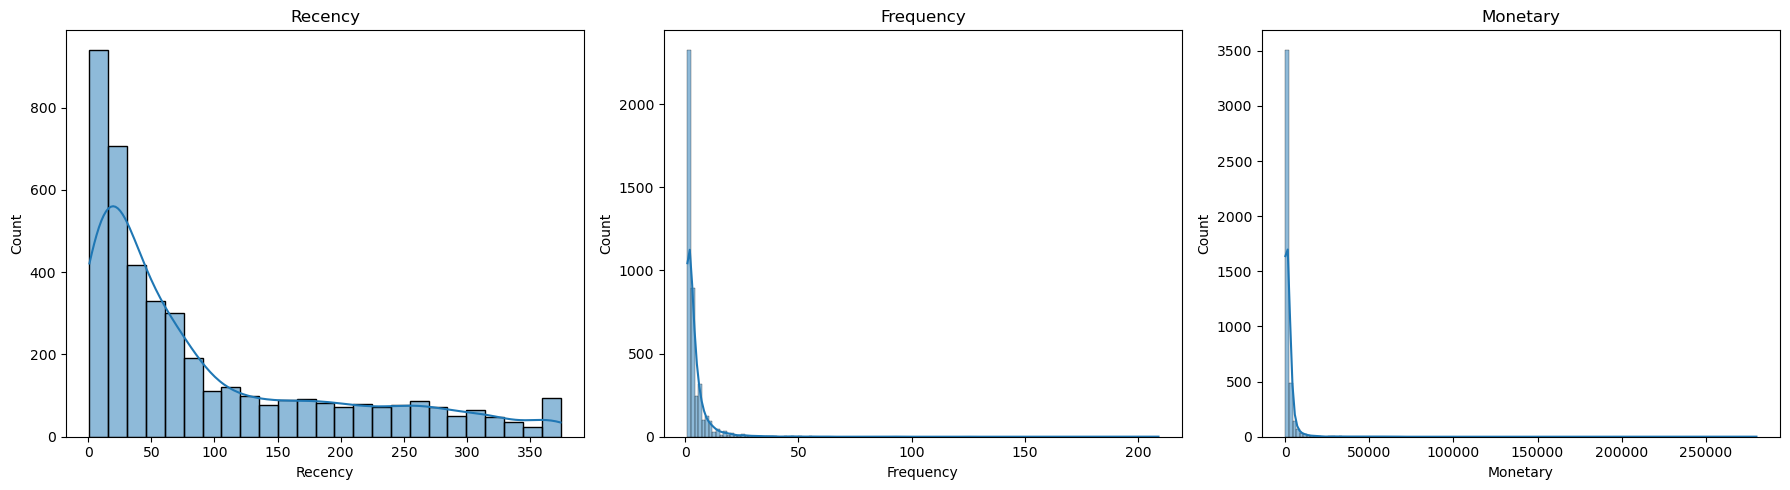

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(rfm["Recency"], ax=axes[0], kde=True)
axes[0].set_title("Recency")

sns.histplot(rfm["Frequency"], ax=axes[1], kde=True)
axes[1].set_title("Frequency")

sns.histplot(rfm["Monetary"], ax=axes[2], kde=True)
axes[2].set_title("Monetary")

plt.tight_layout()
plt.show()

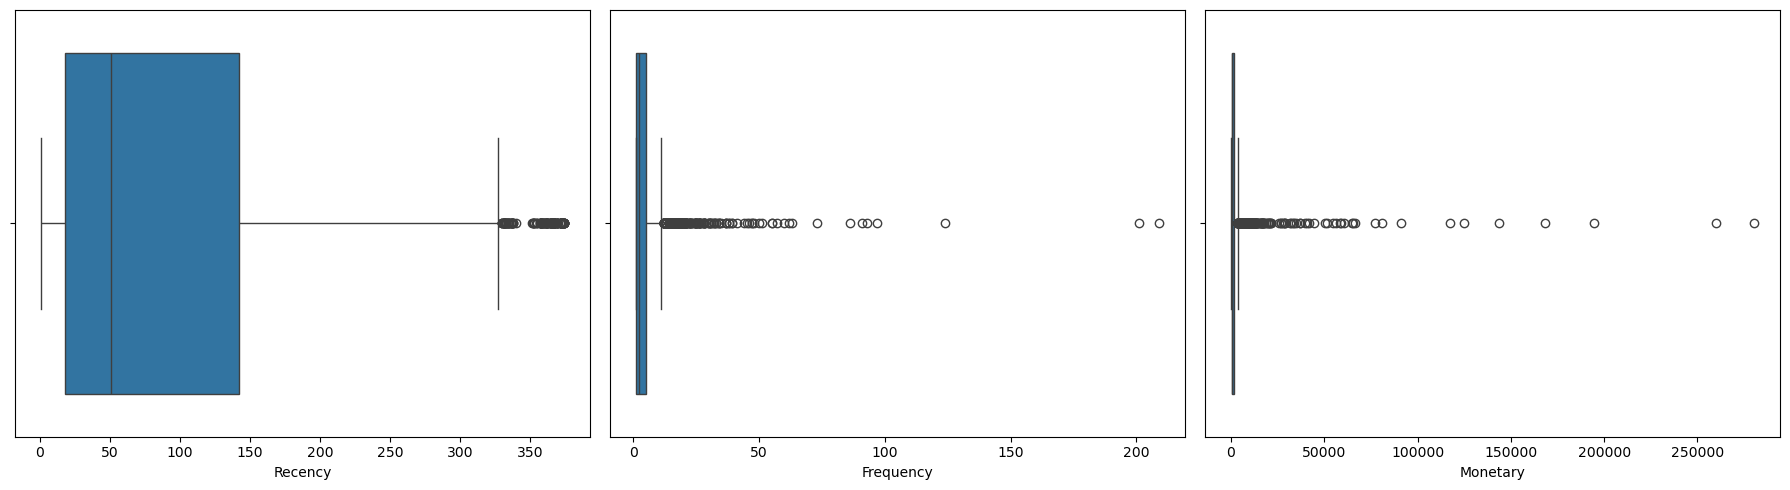

In [33]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.boxplot(x=rfm["Recency"], ax=axes[0])
sns.boxplot(x=rfm["Frequency"], ax=axes[1])
sns.boxplot(x=rfm["Monetary"], ax=axes[2])

plt.tight_layout()
plt.show()

### Checking Feature Skewness

The skewness of the **Recency**, **Frequency**, and **Monetary** features was calculated to assess the shape of their distributions. Highly skewed features can negatively affect the performance of clustering algorithms because a small number of extreme values may dominate distance calculations.

Evaluating skewness helps determine whether a transformation is required before applying clustering techniques.

In [34]:
rfm.skew()

Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64

### Skewness Analysis

The skewness values indicate that all three RFM features are positively skewed.

- **Recency (1.25):** Right-skewed, indicating that while many customers purchased recently, some customers have not made a purchase for a long period.
- **Frequency (12.07):** Extremely right-skewed, showing that most customers make only a few purchases, while a small number purchase very frequently.
- **Monetary (19.34):** Extremely right-skewed, indicating that most customers spend relatively small amounts, whereas a few customers contribute exceptionally high spending.

These highly skewed distributions may negatively affect distance-based clustering algorithms. Therefore, a logarithmic transformation is applied to reduce skewness and make the feature distributions more balanced.

### Applying Logarithmic Transformation

A logarithmic transformation (`log1p`) is applied to the RFM features. This transformation compresses large values more than smaller values, reducing skewness while preserving the relative ordering of customers. The transformed features are expected to be more suitable for clustering.

In [35]:
rfm_log = np.log1p(rfm)

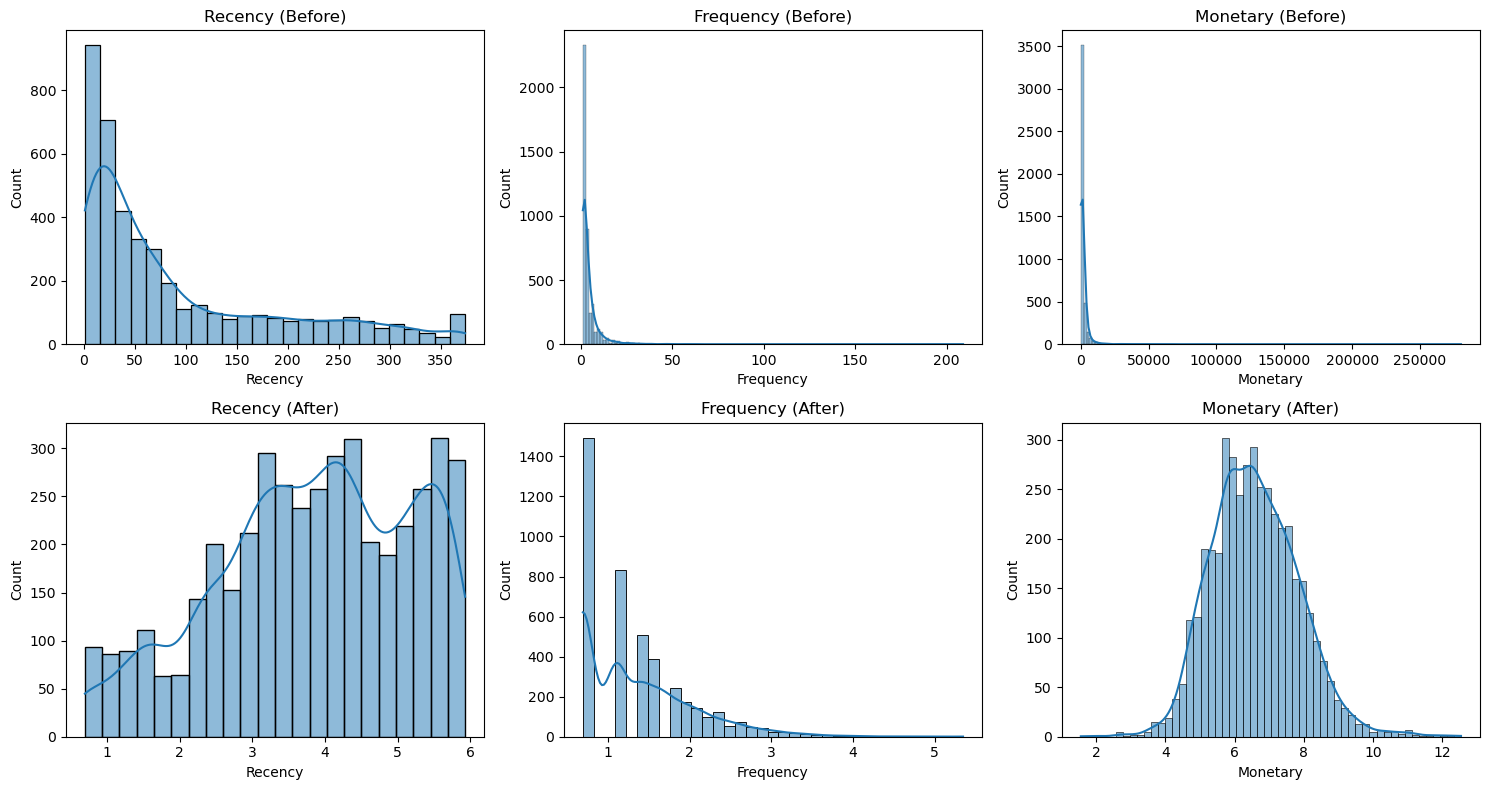

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Before
sns.histplot(rfm["Recency"], ax=axes[0,0], kde=True)
axes[0,0].set_title("Recency (Before)")

sns.histplot(rfm["Frequency"], ax=axes[0,1], kde=True)
axes[0,1].set_title("Frequency (Before)")

sns.histplot(rfm["Monetary"], ax=axes[0,2], kde=True)
axes[0,2].set_title("Monetary (Before)")

# After
sns.histplot(rfm_log["Recency"], ax=axes[1,0], kde=True)
axes[1,0].set_title("Recency (After)")

sns.histplot(rfm_log["Frequency"], ax=axes[1,1], kde=True)
axes[1,1].set_title("Frequency (After)")

sns.histplot(rfm_log["Monetary"], ax=axes[1,2], kde=True)
axes[1,2].set_title("Monetary (After)")

plt.tight_layout()
plt.show()

In [37]:
rfm_log.skew()

Recency     -0.379169
Frequency    1.208652
Monetary     0.396599
dtype: float64

### Effect of the Logarithmic Transformation

The logarithmic transformation significantly reduced the skewness of the RFM features.

- **Recency** changed from 1.25 to -0.38, resulting in an approximately symmetric distribution.
- **Frequency** decreased from 12.07 to 1.21, substantially reducing the influence of extremely frequent customers.
- **Monetary** decreased from 19.34 to 0.40, producing a much more balanced distribution.

Overall, the transformed RFM features are better suited for distance-based clustering algorithms such as K-Means.

## Feature Scaling

Although the logarithmic transformation reduced the skewness of the RFM features, their numerical ranges are still different. Therefore, the transformed features are standardized using **StandardScaler** so that each feature contributes equally to the clustering process.

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

## Determining the Optimal Number of Clusters

Before applying **K-Means** clustering, the optimal number of clusters must be determined. Selecting too few clusters may combine customers with different purchasing behaviors, while selecting too many clusters may produce unnecessary or insignificant segments.

Two validation techniques are used:

- **Elbow Method**, which evaluates how the within-cluster variation changes as the number of clusters increases.
- **Silhouette Score**, which measures how well customers fit within their assigned cluster compared to other clusters.

The results of both methods are used to select the most appropriate number of customer segments.

### Elbow Method

The Elbow Method calculates the **Within-Cluster Sum of Squares (WCSS)**, also called inertia, for different numbers of clusters. As the number of clusters increases, inertia decreases because customers are grouped more closely.

The optimal number of clusters is identified at the point where the reduction in inertia begins to slow noticeably, forming an "elbow" in the curve.

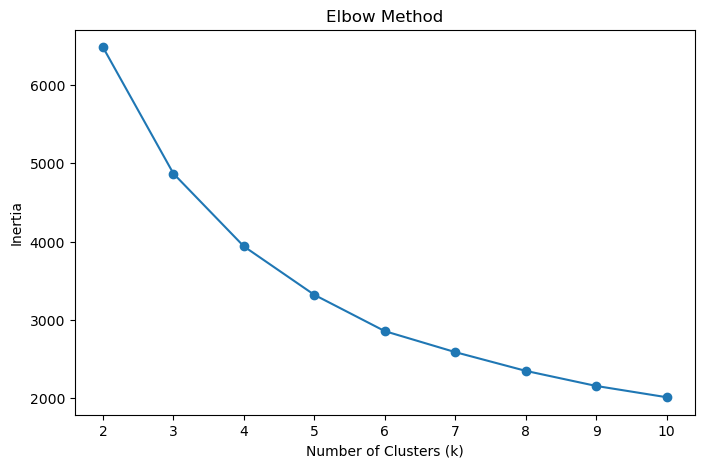

In [76]:
from sklearn.cluster import KMeans

inertia = []

K = range(2,11)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

The elbow appears at **k = 3**, indicating that increasing the number of clusters beyond three results in only a small improvement in within-cluster variation. Therefore, three clusters are considered a suitable choice for further evaluation.

### Silhouette Analysis

The **Silhouette Score** evaluates the quality of clustering by measuring how similar each customer is to its own cluster compared with other clusters.

A higher silhouette score indicates better-separated and more cohesive clusters. The value of k with the highest silhouette score is considered a strong candidate for the optimal number of clusters.

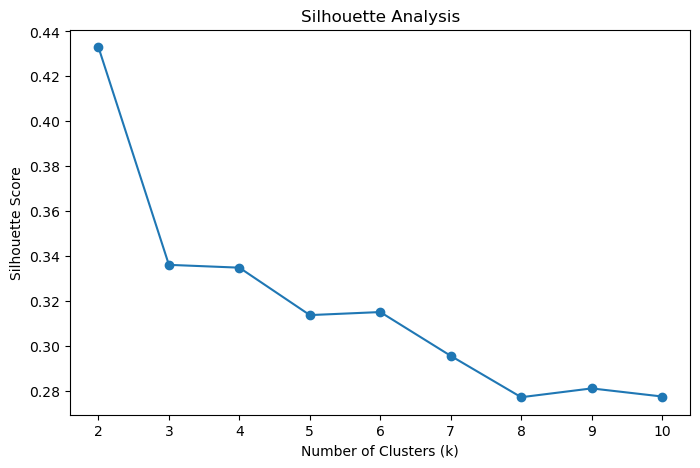

In [40]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(rfm_scaled)
    scores.append(silhouette_score(rfm_scaled, labels))

plt.figure(figsize=(8,5))
plt.plot(range(2,11), scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

The highest silhouette score is obtained when **k = 3**, indicating that three clusters provide the best balance between cluster cohesion and separation.

## Selected Number of Clusters

Both the **Elbow Method** and **Silhouette Analysis** were used to determine the optimal number of clusters.

Based on these results, k = 3 was selected for **K-Means** clustering because it provides a good balance between compact clusters and clear separation between customer groups.

## K-Means Clustering

Based on the results of the **Elbow Method** and **Silhouette Analysis**, **K-Means** clustering is applied using the selected number of clusters.

Each customer is assigned to a cluster according to similarities in their **Recency**, **Frequency**, and **Monetary (RFM)** characteristics.

In [41]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [42]:
rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,167.494917,1.350990,360.420268
1,17.067097,13.282581,7859.031768
2,44.361275,3.372491,1253.148638


## Cluster Profiling

The average **Recency**, **Frequency**, and **Monetary (RFM)** values of each cluster were examined to understand customer purchasing behavior.

- **Cluster 0:** Customers have the highest **Recency** and the lowest **Frequency** and **Monetary** values, indicating inactive or at-risk customers who purchase infrequently and spend relatively little.

- **Cluster 1:** Customers have the lowest **Recency** and the highest **Frequency** and **Monetary** values, representing loyal and high-value customers who purchase frequently and contribute the highest revenue.

- **Cluster 2:** Customers exhibit moderate **Recency**, **Frequency**, and **Monetary** values, representing regular customers with consistent purchasing behavior and moderate spending.

These customer segments provide valuable insights for developing targeted marketing and customer retention strategies.

In [43]:
rfm["Cluster"].value_counts().sort_index()

Cluster
0    1869
1     775
2    1694
Name: count, dtype: int64

### Cluster Sizes

The K-Means algorithm divided the 4,338 customers into three segments.

- **Cluster 0 (Inactive Customers):** 1,869 customers (43.1%)
- **Cluster 1 (Loyal Customers):** 775 customers (17.9%)
- **Cluster 2 (Regular Customers):** 1,694 customers (39.0%)

The largest segment consists of inactive customers, accounting for 43.1% of all customers. Loyal customers represent the smallest segment at 17.9%, while regular customers account for 39.0% of the customer base.

This distribution is consistent with typical business scenarios, where a relatively small group of loyal customers generates high value, while larger groups of regular and inactive customers offer opportunities for retention and re-engagement strategies.

## PCA Visualization of Customer Segments

The RFM dataset contains three features: **Recency**, **Frequency**, and **Monetary**. Since it is difficult to visualize customer relationships in three dimensions, **Principal Component Analysis (PCA)** was applied to reduce the feature space to two dimensions.

**PCA** transforms the original features into new components that retain most of the variation in the data. The resulting two-dimensional representation allows the customer segments identified by **K-Means** clustering to be visualized and evaluated.

In [44]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(rfm_scaled)

In [45]:
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = rfm["Cluster"].values

In [46]:
print(pca.explained_variance_ratio_)

[0.75078634 0.18786648]


In [47]:
sum(pca.explained_variance_ratio_)

np.float64(0.9386528181989526)

### PCA Results

The first principal component (**PC1**) explains approximately **75.1%** of the variance in the dataset, while the second principal component (**PC2**) explains approximately **18.8%**.

Together, the first two principal components capture approximately **93.9%** of the total variance. This indicates that the two-dimensional **PCA** representation preserves most of the information contained in the original **RFM features** and provides a reliable visualization of customer segments.

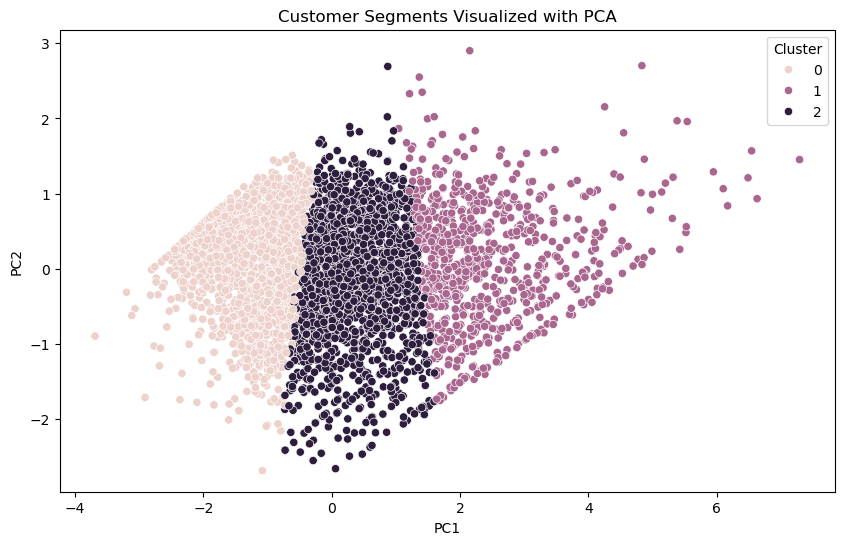

In [48]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster"
)

plt.title("Customer Segments Visualized with PCA")
plt.show()

### Interpretation of the PCA Visualization

The **PCA** scatter plot shows that the customer segments are reasonably separated in the reduced feature space. Although some overlap exists between clusters, distinct groupings can still be observed. This suggests that the **K-Means** algorithm successfully identified meaningful differences in customer purchasing behavior.

## t-SNE Visualization

**t-SNE (t-Distributed Stochastic Neighbor Embedding)** was applied to visualize customer segments in a two-dimensional space. Unlike **PCA**, t-SNE focuses on preserving local relationships between observations, which can reveal cluster structures more clearly.

The visualization provides an additional perspective on the separation of customer segments identified by **K-Means** clustering.

In [49]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

tsne_results = tsne.fit_transform(rfm_scaled)

In [50]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

tsne_results = tsne.fit_transform(rfm_scaled)

In [51]:
tsne_df = pd.DataFrame(
    tsne_results,
    columns=["TSNE1", "TSNE2"]
)

tsne_df["Cluster"] = rfm["Cluster"].values

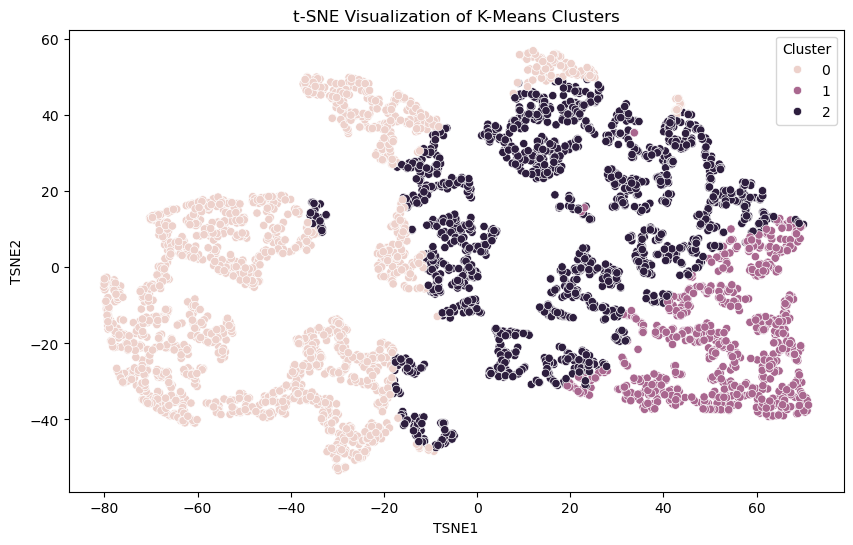

In [52]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="Cluster"
)

plt.title("t-SNE Visualization of K-Means Clusters")
plt.show()

### t-SNE Visualization Summary

The t-SNE visualization shows distinct customer groups with limited overlap between clusters. Compared with PCA, the clusters appear more clearly separated, suggesting that the customer segments identified by K-Means represent meaningful differences in purchasing behavior.

This visualization further supports the validity of the customer segmentation results.

### Visualization Comparison

Both PCA and t-SNE were used to visualize the customer segments identified by K-Means clustering.

While PCA provided a useful overview of the data structure, the clusters exhibited some overlap in the reduced feature space. In contrast, t-SNE produced a clearer separation between customer groups by preserving local relationships among observations.

The t-SNE visualization provides additional evidence that the identified customer segments represent distinct purchasing behaviors.

## Hierarchical Clustering

To further evaluate customer segmentation, **Hierarchical Clustering** was applied as an alternative clustering method. Unlike **K-Means**, hierarchical clustering builds a hierarchy of clusters based on customer similarity.

A **dendrogram** is used to visualize the merging process and identify a suitable number of clusters by examining the distances at which customer groups are combined.

In [53]:
from scipy.cluster.hierarchy import linkage, dendrogram

In [54]:
linkage_matrix = linkage(rfm_scaled, method='ward')

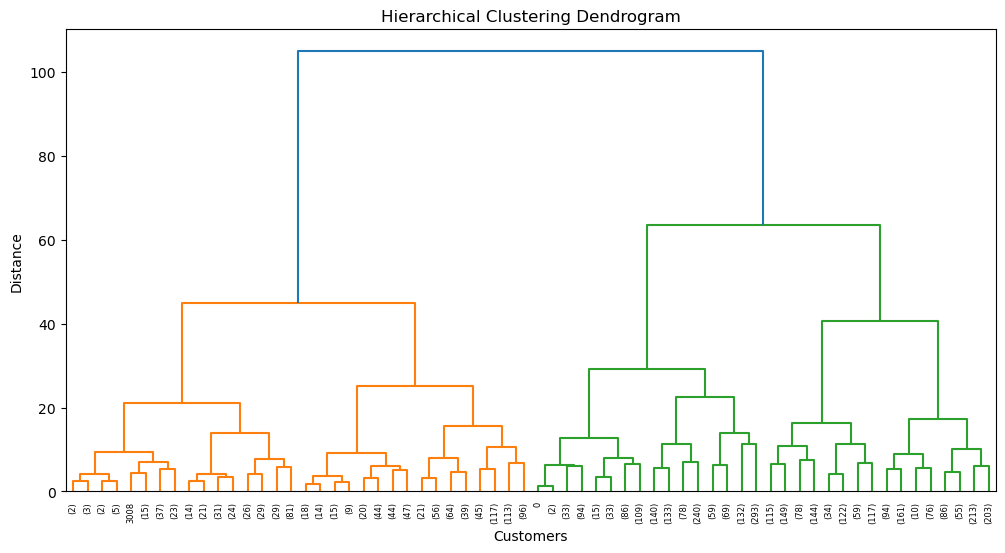

In [55]:
plt.figure(figsize=(12,6))

dendrogram(
    linkage_matrix,
    truncate_mode='level',
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

### Dendrogram Analysis

The **dendrogram** shows how customer groups are merged based on similarity. A significant increase in linkage distance can be observed in the final stages of the hierarchy, indicating the presence of distinct customer segments.

By examining the large vertical gaps in the dendrogram and placing a horizontal cut before the major cluster merges, a four-cluster solution was selected.

Therefore, **Hierarchical Clustering** was performed using four clusters to analyze customer purchasing behavior.

In [60]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

rfm["Hierarchical_Cluster"] = hierarchical.fit_predict(rfm_scaled)

## Hierarchical Cluster Profiling

The resulting hierarchical clusters were analyzed using the average **Recency**, **Frequency**, and **Monetary** values to understand the purchasing behavior of customers within each segment.

In [62]:
rfm.groupby("Hierarchical_Cluster")[["Recency","Frequency","Monetary"]].mean()

,Recency,Frequency,Monetary
Hierarchical_Cluster,,,
0,146.576923,1.262821,270.308351
1,9.685039,5.460630,1811.131142
2,91.006592,3.460119,1558.658572
3,13.002915,20.276968,13640.795277


In [64]:
rfm["Hierarchical_Cluster"].value_counts()

Hierarchical_Cluster
0    1716
2    1517
1     762
3     343
Name: count, dtype: int64

## Hierarchical Cluster Profiling

The hierarchical clustering solution produced four customer segments with distinct purchasing behaviors.

- **Cluster 0:** Customers have the highest **Recency** and the lowest **Frequency** and **Monetary** values. These customers represent inactive or at-risk customers who purchase infrequently and contribute relatively little revenue.

- **Cluster 1:** Customers have low **Recency**, moderate **Frequency**, and moderate **Monetary** values. These customers are active customers who purchase regularly and contribute consistent revenue.

- **Cluster 2:** Customers exhibit moderate **Recency**, **Frequency**, and **Monetary** values. This segment represents regular customers with average purchasing behavior.

- **Cluster 3:** Customers have very low **Recency** and the highest **Frequency** and **Monetary** values. These customers represent high-value customers who purchase frequently and generate the highest revenue.

The four-cluster solution provides a more detailed segmentation than the three-cluster K-Means solution by separating high-value customers from other active customers.

## DBSCAN Clustering

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** was applied as a density-based clustering technique. Unlike **K-Means** and **Hierarchical Clustering**, DBSCAN does not require specifying the number of clusters in advance.

The algorithm groups customers based on density and can identify unusual customers as noise points. This makes **DBSCAN** useful for detecting potential outliers in customer purchasing behavior.

In [65]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

rfm["DBSCAN_Cluster"] = dbscan.fit_predict(rfm_scaled)

In [66]:
rfm["DBSCAN_Cluster"].value_counts().sort_index()

DBSCAN_Cluster
-1      62
 0    2791
 1    1485
Name: count, dtype: int64

In [67]:
n_clusters = len(set(rfm["DBSCAN_Cluster"])) - (
    1 if -1 in rfm["DBSCAN_Cluster"] else 0
)

print("Number of clusters:", n_clusters)

Number of clusters: 3


In [68]:
dbscan_profile = rfm[rfm["DBSCAN_Cluster"] != -1]

dbscan_profile.groupby("DBSCAN_Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

,Recency,Frequency,Monetary
DBSCAN_Cluster,,,
0,59.151200,5.370118,2021.950123
1,156.868013,1.000000,354.090270


### Cluster Profiling

The average **Recency, Frequency, and Monetary** values were calculated for each cluster to understand customer purchasing behavior.

**Cluster 0** exhibits lower **Recency**, higher **Frequency**, and higher **Monetary** values, indicating active customers who purchase more frequently and generate higher revenue.

**Cluster 1** exhibits higher **Recency**, lower **Frequency**, and lower **Monetary** values, indicating inactive customers who purchase less frequently and contribute lower revenue.

Overall, **DBSCAN** separates customers into broad active and inactive groups.

In [69]:
noise_points = (rfm["DBSCAN_Cluster"] == -1).sum()

print("Noise Points:", noise_points)

Noise Points: 62


In [70]:
noise_percentage = (
    (rfm["DBSCAN_Cluster"] == -1).sum()
    / len(rfm)
) * 100

print(f"Noise Percentage: {noise_percentage:.2f}%")

Noise Percentage: 1.43%


### Cluster Distribution

**DBSCAN** identified two customer clusters and **62 noise points**.

The noise points represent customers whose purchasing behavior differs significantly from the majority of customers and may be considered potential outliers. These customers may exhibit unusually high or low purchasing activity compared to the rest of the customer base.

### PCA Visualization

**Principal Component Analysis (PCA)** was used to reduce the three-dimensional **RFM feature** space into two dimensions for visualization purposes.

The scatter plot illustrates the customer groups identified by **DBSCAN** and highlights the noise points detected by the algorithm.

In [71]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(rfm_scaled)

pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"]
)

pca_df["DBSCAN_Cluster"] = rfm["DBSCAN_Cluster"].values

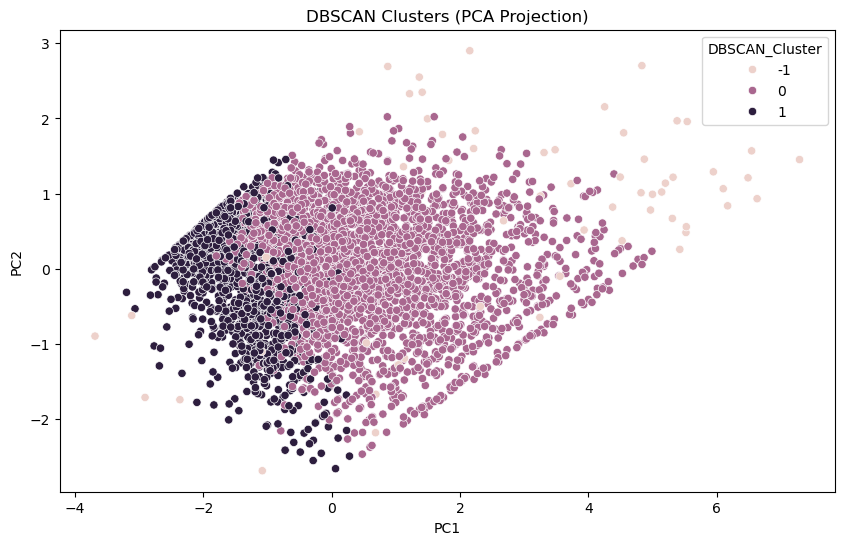

In [72]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="DBSCAN_Cluster"
)

plt.title("DBSCAN Clusters (PCA Projection)")
plt.show()

### DBSCAN Summary

**DBSCAN** successfully identified two major customer groups and detected **62 outlier customers**. While the algorithm was effective in recognizing unusual customer behavior, it produced less detailed segmentation than **K-Means** and **Hierarchical Clustering**.

Therefore, **DBSCAN** is valuable as an anomaly detection technique, whereas **K-Means** and **Hierarchical Clustering** provide more actionable customer segments for marketing and customer relationship management.

In [73]:
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,167.49,1.35,360.42
1,17.07,13.28,7859.03
2,44.36,3.37,1253.15


In [74]:
cluster_profile.index = [
    "Inactive Customers",
    "Loyal Customers",
    "Regular Customers"
]

cluster_profile

,Recency,Frequency,Monetary
Inactive Customers,167.49,1.35,360.42
Loyal Customers,17.07,13.28,7859.03
Regular Customers,44.36,3.37,1253.15


## Customer Segment Analysis

### Loyal Customers

Loyal customers have the lowest average **Recency (17 days)**, the highest **Frequency (13.28 purchases)**, and the highest **Monetary value (£7,859)**. This indicates that they purchase recently, buy frequently, and contribute the largest share of revenue. These customers represent the most valuable customer segment.

### Inactive Customers

Inactive customers have the highest average **Recency (167 days)**, the lowest **Frequency (1.35 purchases)**, and the lowest **Monetary value (£360)**. This indicates that they have not purchased recently, buy infrequently, and contribute relatively little revenue. These customers are at risk of **churn**.

### Regular Customers

Regular customers have moderate **Recency (44 days)**, **Frequency (3.37 purchases)**, and **Monetary value (£1,253)**. They purchase periodically and generate moderate revenue. This segment represents customers with the potential to become **loyal customers** through targeted marketing strategies.

## Comparison of Clustering Methods

Three clustering techniques were applied to the RFM dataset: **K-Means**, **Hierarchical Clustering**, and **DBSCAN**.

**K-Means** produced three customer segments consisting of loyal customers, regular customers, and inactive customers. **Hierarchical Clustering** identified four customer segments, further separating a group of high-value customers from the broader active customer segment.

**DBSCAN** identified two major customer groups and a small number of outlier customers. While this method was effective for anomaly detection, it produced less detailed customer segmentation than **K-Means** and **Hierarchical Clustering**.

**PCA** and **t-SNE** visualizations further supported the clustering results. In particular, **t-SNE** showed clear separation between the customer segments identified by **K-Means**, indicating meaningful differences in purchasing behavior.

Overall, **K-Means** provided the most interpretable and actionable customer segments, making it the most suitable method for customer segmentation in this project.

## Comparison of Clustering Methods

Three clustering techniques were applied to the RFM dataset: **K-Means**, **Hierarchical Clustering**, and **DBSCAN**.

**K-Means** produced three customer segments consisting of loyal customers, regular customers, and inactive customers. **Hierarchical Clustering** identified four customer segments, further separating a group of high-value customers from the broader active customer segment.

**DBSCAN** identified two major customer groups and a small number of outlier customers. While this method was effective for anomaly detection, it produced less detailed customer segmentation than **K-Means** and **Hierarchical Clustering**.

**PCA** and **t-SNE** visualizations further supported the clustering results. In particular, **t-SNE** showed clear separation between the customer segments identified by **K-Means**, indicating meaningful differences in purchasing behavior.

Overall, **K-Means** provided the most interpretable and actionable customer segments, making it the most suitable method for customer segmentation in this project.

# Conclusion

This project applied **RFM analysis** and clustering techniques to segment customers based on their purchasing behavior.

After data cleaning and preprocessing, **Recency, Frequency, and Monetary (RFM)** features were generated for each customer. To improve clustering performance, skewed distributions were reduced through **logarithmic transformation**, and the features were standardized using **feature scaling**.

Three clustering algorithms were evaluated: **K-Means**, **Hierarchical Clustering**, and **DBSCAN**. The **Elbow Method** and **Silhouette Analysis** indicated that three clusters were appropriate for **K-Means**. The resulting customer segments were identified as **Loyal Customers**, **Regular Customers**, and **Inactive Customers**.

**PCA** and **t-SNE** visualizations were used to explore the cluster structure. While **PCA** provided an overview of the data distribution, **t-SNE** revealed a clearer separation between customer segments, further supporting the validity of the clustering results.

**Hierarchical Clustering** identified four customer segments, including a distinct group of **High-Value Customers**, providing a more detailed segmentation structure. **DBSCAN** successfully detected **62 anomalous customers** but generated less detailed customer segments, making it more suitable for outlier detection than customer segmentation.

Based on cluster quality, interpretability, and business relevance, **K-Means** was selected as the most suitable clustering method. The identified customer segments can help businesses develop targeted marketing campaigns, improve customer retention, and increase overall revenue through targeted marketing strategies.